
🔹 Training model with 8 filters...
Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9029 - loss: 0.3326 - val_accuracy: 0.9678 - val_loss: 0.1105
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9711 - loss: 0.0959 - val_accuracy: 0.9779 - val_loss: 0.0768
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9780 - loss: 0.0705 - val_accuracy: 0.9808 - val_loss: 0.0684

🔹 Training model with 16 filters...
Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9298 - loss: 0.2443 - val_accuracy: 0.9761 - val_loss: 0.0819
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9780 - loss: 0.0693 - val_accuracy: 0.9827 - val_loss: 0.0627
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9849 - loss: 0.0480 - val_accuracy: 0.9840 - val_loss: 0.0592

🔹 Training model with 32 filters...
Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9409 - loss: 0.1968 - val_accuracy: 0.9793 - val_loss: 0.

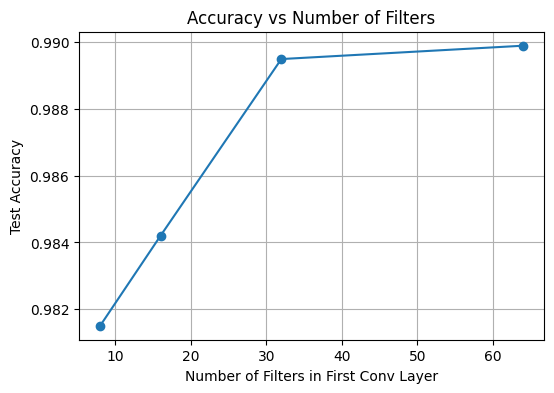

Filters: 8 → Test Accuracy: 0.9815
Filters: 16 → Test Accuracy: 0.9842
Filters: 32 → Test Accuracy: 0.9895
Filters: 64 → Test Accuracy: 0.9899


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

#  بارگذاری داده MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# نرمال‌سازی و تغییر شکل برای CNN
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

#  تابعی برای ساخت مدل با تعداد فیلتر دلخواه
def create_cnn(num_filters):
    model = keras.Sequential([
        layers.Conv2D(num_filters, (3,3), activation='relu', input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(num_filters*2, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

#  آزمایش مدل‌ها با تعداد فیلتر مختلف
filter_values = [8, 16, 32, 64]
results = {}

for f in filter_values:
    print(f"\n🔹 Training model with {f} filters...")
    model = create_cnn(f)
    history = model.fit(x_train, y_train, epochs=3, batch_size=64,
                        validation_split=0.2, verbose=1)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results[f] = test_acc

# رسم نمودار مقایسه دقت‌ها
plt.figure(figsize=(6,4))
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.title("Accuracy vs Number of Filters")
plt.xlabel("Number of Filters in First Conv Layer")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()

# چاپ نتایج
for f, acc in results.items():
    print(f"Filters: {f} → Test Accuracy: {acc:.4f}")
